In [1]:
#%matplotlib widget
from src.MFE import *
import numpy as np
import matplotlib.pyplot as plt   
from src.helper import *
from multiprocessing.pool import ThreadPool,Pool
from matplotlib.animation import FuncAnimation
from matplotlib.animation import FFMpegWriter 
import pyvista  as pv
from src.SnapCluster import SnapCluster
from src.visulization import *
import matplotlib.colors as colors
from matplotlib.cm import ScalarMappable
import random
from joblib import Parallel, delayed
import os



%load_ext autoreload
%autoreload 2
%reload_ext autoreload


In [2]:

plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.family']='serif'

In [3]:
discretize_size=30
Lx,Lz=1.75*np.pi,1.2*np.pi
def U_modes(Lx,Lz,discretize_size):
    
    x=np.linspace(0,Lx,discretize_size)
    y=np.linspace(-1,1,discretize_size)
    z=np.linspace(0,Lz,discretize_size)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

    alpha=2*np.pi/Lx
    beta=np.pi/2
    gamma=2*np.pi/Lz

    u1=np.sqrt(2)*np.sin(np.pi*Y/2)
    v1=np.full_like(u1,0)
    w1=np.full_like(u1,0)

    u2=(4/np.sqrt(3))*(np.cos(np.pi*Y/2)**2)*np.cos(gamma*Z)
    v2=np.full_like(u2,0)
    w2=np.full_like(u2,0)

    u3=np.full_like(u2,0)
    v3=(2/np.sqrt(4*gamma**2+np.pi**2))*(2*gamma*np.cos(np.pi*Y/2))*np.cos(gamma*Z)
    w3=(2/np.sqrt(4*gamma**2+np.pi**2))*(np.pi*np.sin(np.pi*Y/2))*np.sin(gamma*Z)

    u4=np.full_like(u2,0)
    v4=np.full_like(u2,0)
    w4=(4/np.sqrt(3))*(np.cos(alpha*X))*(np.cos(np.pi*Y/2)**2)

    u5=np.full_like(u2,0)
    v5=np.full_like(u2,0)
    w5=2*np.sin(alpha*X)*np.sin(np.pi*Y/2)

    c6=(4*np.sqrt(2)/np.sqrt(3*(alpha**2+gamma**2)))
    u6=c6*(-gamma*np.cos(alpha*X))*(np.cos(np.pi*Y/2)**2)*(np.sin(gamma*Z))
    v6=np.full_like(u2,0)
    w6=c6*(alpha*np.sin(alpha*X))*(np.cos(np.pi*Y/2)**2)*(np.cos(gamma*Z))

    c7=(2*np.sqrt(2)/np.sqrt(alpha**2+gamma**2))
    u7=c7*(gamma*np.sin(alpha*X))*(np.sin(np.pi*Y/2))*(np.sin(gamma*Z))
    v7=np.full_like(u2,0)
    w7=c7*(alpha*np.cos(alpha*X))*(np.sin(np.pi*Y/2))*(np.cos(gamma*Z))

    N8=(2*np.sqrt(2)/(np.sqrt((alpha**2+gamma**2)*(4*alpha**2+4*gamma**2+np.pi**2))))
    u8=N8*(np.pi*alpha*np.sin(alpha*X))*(np.sin(np.pi*Y/2))*(np.sin(gamma*Z))
    v8=N8*2*(alpha**2+gamma**2)*(np.cos(alpha*X))*(np.cos(np.pi*Y/2))*(np.sin(gamma*Z))
    w8=N8*(-np.pi*gamma)*(np.cos(alpha*X))*(np.sin(np.pi*Y/2))*(np.cos(gamma*Z))

    u9=np.sqrt(2)*np.sin(3*np.pi*Y/2)
    v9=np.full_like(u2,0)
    w9=np.full_like(u2,0)

    U1=np.array([u1,v1,w1])
    U2=np.array([u2,v2,w2])
    U3=np.array([u3,v3,w3])
    U4=np.array([u4,v4,w4])
    U5=np.array([u5,v5,w5])
    U6=np.array([u6,v6,w6])
    U7=np.array([u7,v7,w7])
    U8=np.array([u8,v8,w8])
    U9=np.array([u9,v9,w9])
    X_coor=np.array([X,Y,Z])
    U_modes=np.array([U1,U2,U3,U4,U5,U6,U7,U8,U9])
    return X_coor,U_modes

X_coor,U_modes=U_modes(Lx,Lz,discretize_size)
U1,U2,U3,U4,U5,U6,U7,U8,U9=U_modes


Text(0, 0.5, 'Dissipation')

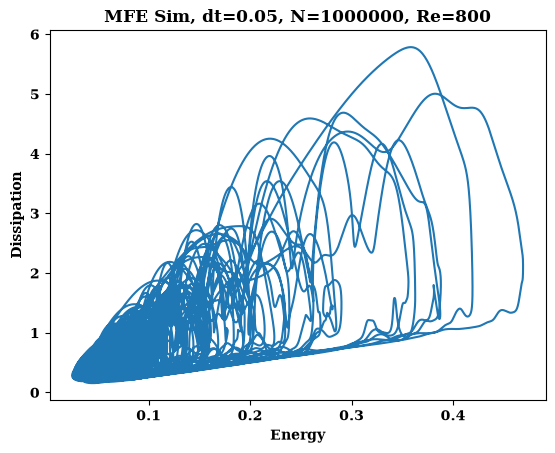

In [4]:
dt,N,istart = 0.05,1010000,10000       
Re=800
caseName=""
Case=create_case_folder(dt,N-istart,Re,Lx,Lz)  
Case = os.path.join(Case, caseName)
data_path=os.path.join(Case,"runTime")
if not os.path.exists(data_path):
    os.makedirs(data_path)  
VTK_path=os.path.join(Case,"VTK")
if not os.path.exists(VTK_path):
    os.makedirs(VTK_path)
x=np.linspace(0,Lx,discretize_size)
y=np.linspace(-1,1,discretize_size)
z=np.linspace(0,Lz,discretize_size)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
sim_time=np.arange(0,N-istart,20)


D,E,a = MFE_Sequence(dt,N,istart,Re=Re,Lx=Lx,Lz=Lz)   # generate data sequence
DE = np.vstack((D,E)).T
plt.close()
figo, axo = plt.subplots()
axo.plot(DE[:, 1], DE[:, 0],zorder=1)
axo.set_title(f'MFE Sim, dt={dt}, N={N-istart}, Re={Re}')
axo.set_xlabel("Energy")
axo.set_ylabel("Dissipation")
#axo.set_facecolor("#EAEBF4")


Time for Ulam-Galerkin Disctrization:1.535817500000121
Number of boxes: 431
Current cluster size: 400
Current cluster size: 300
Current cluster size: 200
Current cluster size: 100
Number of clusters from MST: 10
Time for MST:205.80266260000008


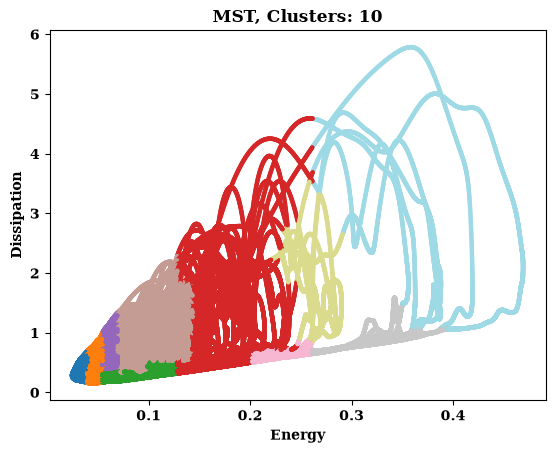

In [5]:
Disctrize_box_size=30
Cluster_size=10
A= SnapCluster(DE,Disctrize_box_size)
CPT=A.repeated_mst_algorithm(Cluster_size,method="kruskal")
nclust=max(A.CPT[-1])+1
cluster_colors, ci = cluster_colors(A.CPT)
cluster_colors = np.array(cluster_colors)

figo, ax = plt.subplots()
ax.scatter(DE[:, 1], DE[:, 0], s=5, c=cluster_colors)
ax.set_xlabel("Energy")
ax.set_ylabel("Dissipation")
ax.set_title(f"MST, Clusters: {nclust}")
figo.savefig(os.path.join(Case, f"MST_reclustering_nclust={nclust}.png"))

In [9]:
#%%

cluster_color=cluster_colors
os.makedirs("frames/clustered_phase_space", exist_ok=True)
Emin,Emax=min(E), max(E)
Dmin,Dmax=min(D), max(D)


def update(idx,frame):
    if not os.path.exists(f"frames/clustered_phase_space/frame_{idx:06d}.png"):
        fig8, axis = plt.subplots()
        axis.set_xlim(Emin, Emax)
        axis.set_ylim(Dmin, Dmax)
        axis.set_xlabel("Energy")#,color="white")
        axis.set_ylabel("Dissipation")#,color="white")
        axis.tick_params(axis="both")#,color='white')
        h = min(frame, len(E))  # avoid exceeding array length
        #x = E[:h]  # must be a sequence
        #y = D[:h]  # must be a sequence
        axis.scatter(E[:h], D[:h], c=cluster_color[:h], s=1, alpha=0.3)
        axis.scatter(E[h], D[h], c='r', s=25)
        axis.set_title(f"Time: {frame*dt}s")#,color="white")
        fig8.tight_layout()
        fig8.savefig(f"frames/clustered_phase_space/frame_{idx:06d}.png", dpi=300)
        plt.close(fig8)

Parallel(n_jobs=-2)(delayed(update)(idx,frame) for idx, frame in enumerate(sim_time));


In [7]:
def run_time(t):
    #axo.scatter(DE[t, 1], DE[t, 0],c="red",zorder=10)
    U_sum = np.zeros_like(U1)
    U_sum+=U1*a[t,0]
    U_sum+=U2*a[t,1]
    U_sum+=U3*a[t,2]
    U_sum+=U4*a[t,3]
    U_sum+=U5*a[t,4]
    U_sum+=U6*a[t,5]
    U_sum+=U7*a[t,6]
    U_sum+=U8*a[t,7]
    U_sum+=U9*a[t,8]

    U,V,W=U_sum
    np.savez(
        os.path.join(data_path,f'{t}.npz'),
        U=U,
        V=V,
        W=W
    )

if __name__ == "__main__":
    
    with ThreadPool() as pool:
        pool.map(run_time,sim_time)


In [6]:
def vtk_writer(i):    
    with np.load(os.path.join(data_path, f"{i}.npz")) as data: 
        U = data["U"] 
        V = data["V"] 
        W = data["W"] 
    grid = pv.StructuredGrid(X, Y, Z) 
    grid["Velocity"]  = np.column_stack([
        U.ravel(order='F'),
        V.ravel(order='F'),
        W.ravel(order='F')])

    grid.save(os.path.join(VTK_path, f"flow_{i}.vts"))
if __name__ == "__main__":
    
    with ThreadPool() as pool:
        pool.map(vtk_writer,sim_time)

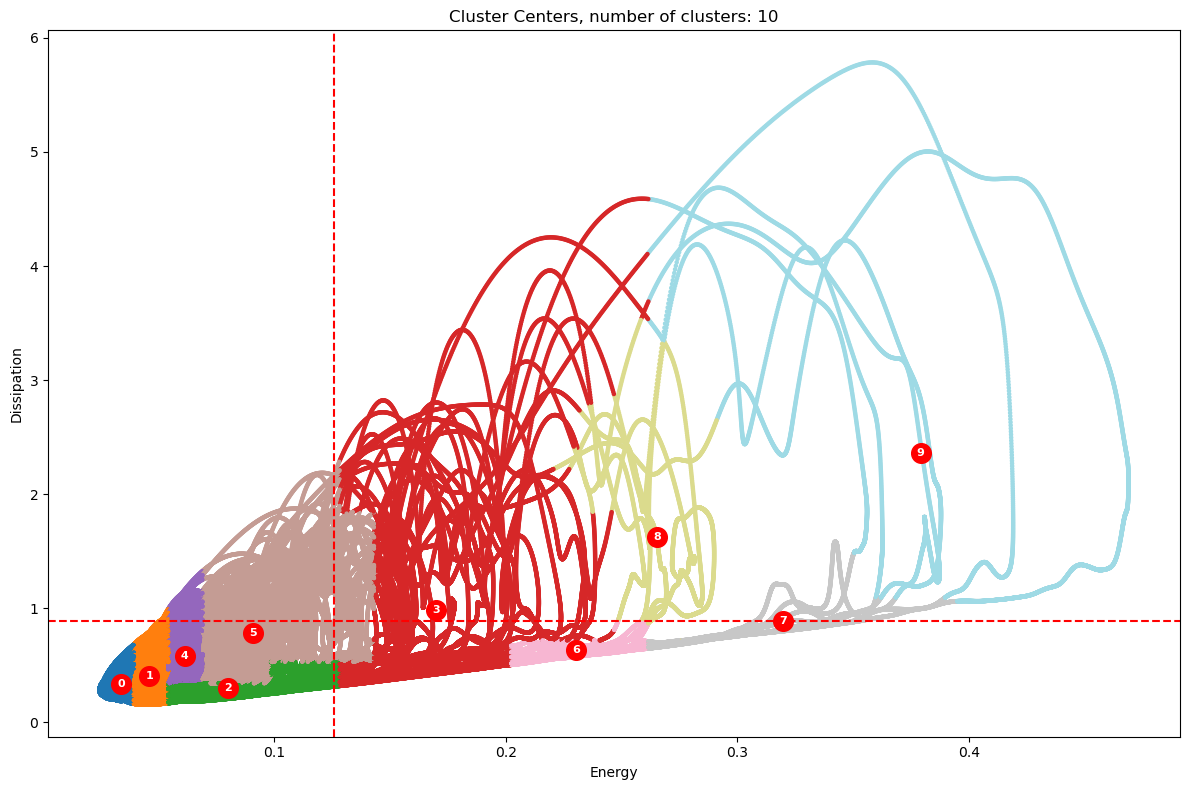

In [26]:
plot_cluster_centers(Case,A.CPT,DE,k=-1)

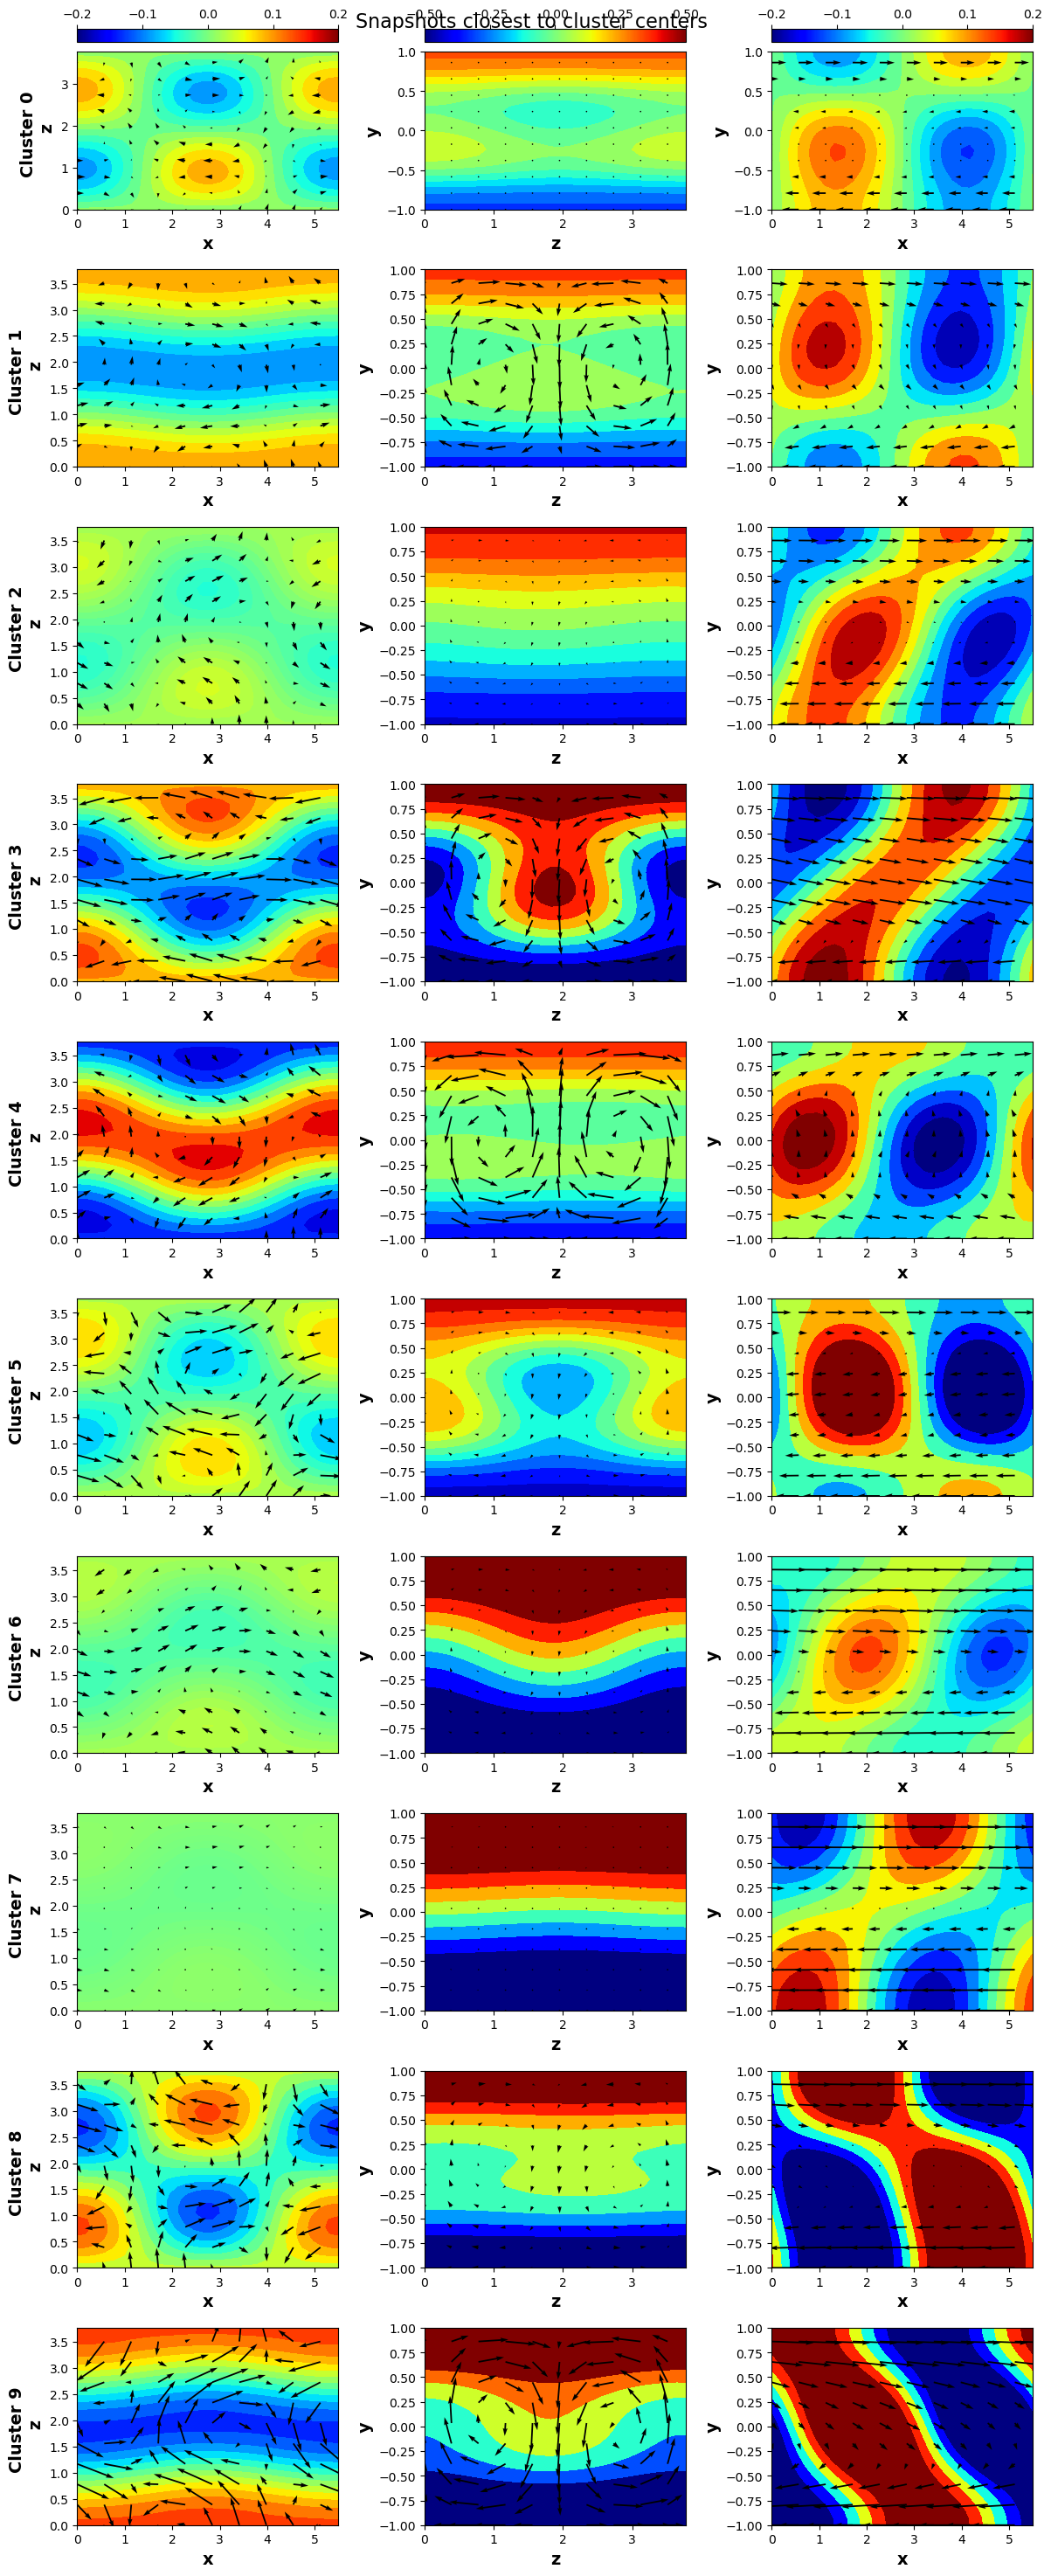

In [25]:
cluster_stage=-1
num_clusters = max(A.CPT[cluster_stage])+1
CC=cluster_centroids(A.CPT,DE,cluster_stage)
cluster_center_points =[]
for i, center in enumerate(CC):
    distances = np.linalg.norm(DE - center, axis=1)
    closest_index = np.argmin(distances)
    cluster_center_points.append(closest_index)
cluster_center_points = np.array(cluster_center_points)
ind=list(np.abs(sim_time[:, None]-cluster_center_points).argmin(axis=0))
cluster_center_points_in_data = sim_time[ind]

###Plotting
k = discretize_size // 2
quiver_skip = 3
quiver_scale = 1
quiver_skip_X_Z = 3
quiver_scale_X_Z = 5
quiver_skip_Y_X = 3
quiver_scale_Y_X = 5
plt.close('all')

fig, ax = plt.subplots(num_clusters,3,figsize=(12,3*num_clusters))

vmin_1, vmax_1 = -0.2, 0.2
vmin_2, vmax_2 = -0.5, 0.5
vmin_3, vmax_3 = -0.2, 0.2

norm_1 = colors.Normalize(vmin_1, vmax_1)
norm_2 = colors.Normalize(vmin_2, vmax_2)
norm_3 = colors.Normalize(vmin_3, vmax_3)

tick_values_1 = np.linspace(vmin_1, vmax_1, num=5)
tick_values_2 = np.linspace(vmin_2, vmax_2, num=5)
tick_values_3 = np.linspace(vmin_3, vmax_3, num=5)
sm1 = ScalarMappable(norm=norm_1, cmap='jet')
sm2 = ScalarMappable(norm=norm_2, cmap='jet')
sm3 = ScalarMappable(norm=norm_3, cmap='jet')

for i, center_point in enumerate(cluster_center_points_in_data):
    U_val=np.load(os.path.join(data_path,f"{center_point}.npz"))
    U,V,W=U_val["U"],U_val["V"],U_val["W"]

    # --------------------------------------------------
    # Plot Z-X-Plane
    # --------------------------------------------------

    X2DY = X[:, k, :]
    Z2DY = Z[:, k, :]
    U2DY = U[:, k, :]
    V2DY = V[:, k, :]
    W2DY = W[:, k, :]

    # Colored contour
    cont0 = ax[i,0].contourf(
        X2DY,
        Z2DY,
        V2DY,
        levels=10,
        cmap='jet',
        #vmin=-0.2,
        #vmax=0.2,
        norm=norm_1
    )

    ax[i,0].quiver(
        X2DY[::quiver_skip_X_Z, ::quiver_skip_X_Z],
        Z2DY[::quiver_skip_X_Z, ::quiver_skip_X_Z],
        U2DY[::quiver_skip_X_Z, ::quiver_skip_X_Z],
        W2DY[::quiver_skip_X_Z, ::quiver_skip_X_Z],
        color='k',
        scale=quiver_scale_X_Z
    )

    # Labels
    ax[i,0].set_xlabel('x', fontsize=14, fontweight='bold')
    ax[i,0].set_ylabel(f'Cluster {i} \n z', fontsize=14, fontweight='bold')

    # Colorbar
    #cbar = plt.colorbar(cont,orientation='horizontal',location='top')
    #cbar.ax.tick_params(labelsize=14)
    #ax[i,0].tick_params(labelsize=14)
    #cbar.set_ticks([-0.2, -0.1, 0, 0.1, 0.2])

    # --------------------------------------------------
    # Plot Z-Y-Plane
    # --------------------------------------------------

    Y2DX = Y[k, :, :]
    Z2DX = Z[k, :, :]

    U2DX = U.mean(axis=0)
    V2DX = V.mean(axis=0)
    W2DX = W.mean(axis=0)

    # Colored contour
    cont1 = ax[i,1].contourf(
        Z2DX,
        Y2DX,
        U2DX,
        levels=10,
        cmap='jet',
        #vmin=-0.2,
        #vmax=0.2,
        norm=norm_2
    )

    ax[i,1].quiver(
        
        Z2DX[::quiver_skip, ::quiver_skip],
        Y2DX[::quiver_skip, ::quiver_skip],
        W2DX[::quiver_skip, ::quiver_skip],
        V2DX[::quiver_skip, ::quiver_skip],
        color='k',
        scale=quiver_scale
    )

    # Labels
    ax[i,1].set_xlabel('z', fontsize=14, fontweight='bold')
    ax[i,1].set_ylabel('y', fontsize=14, fontweight='bold')

    # Colorbar
    #cbar = plt.colorbar(cont,orientation='horizontal',location='top')
    #cbar.ax.tick_params(labelsize=14)

    #ax[i,1].tick_params(labelsize=14)

    # --------------------------------------------------
    # Plot Y-X-Plane
    # --------------------------------------------------

    Y2DZ = Y[:, :, k]
    X2DZ = X[:, :, k]

    V2DZ = V[:, :, k]
    U2DZ = U[:, :, k]
    W2DZ = W[:, :, k]


    # Colored contour
    cont2 = ax[i,2].contourf(
        X2DZ,
        Y2DZ,
        W2DZ,
        levels=10,
        cmap='jet',
        #vmin=-0.2,
        #vmax=0.2,
        norm=norm_3
    )

    ax[i,2].quiver(
        
        X2DZ[::quiver_skip_Y_X, ::quiver_skip_Y_X],
        Y2DZ[::quiver_skip_Y_X, ::quiver_skip_Y_X],
        U2DZ[::quiver_skip_Y_X, ::quiver_skip_Y_X],
        V2DZ[::quiver_skip_Y_X, ::quiver_skip_Y_X],
        color='k',
        scale=quiver_scale_Y_X
    )

    # Labels
    ax[i,2].set_xlabel('x', fontsize=14, fontweight='bold')
    ax[i,2].set_ylabel('y', fontsize=14, fontweight='bold')

    # Colorbar
    #cbar = plt.colorbar(cont,orientation='horizontal',location='top')
    #cbar.ax.tick_params(labelsize=14)

    #ax[i,2].tick_params(labelsize=14)
fig.colorbar(sm1, ax=ax[0, 0], orientation='horizontal', location='top',ticks=tick_values_1)
fig.colorbar(sm2, ax=ax[0, 1], orientation='horizontal', location='top',ticks=tick_values_2)
fig.colorbar(sm3, ax=ax[0, 2], orientation='horizontal', location='top',ticks=tick_values_3)
fig.suptitle(f"Snapshots closest to cluster centers", fontsize=16)
plt.tight_layout()
plt.show()



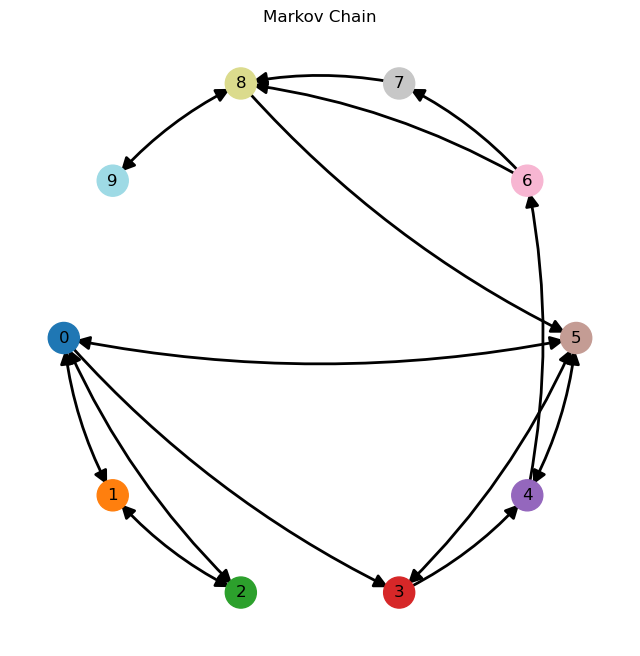

In [12]:
plot_markov_chain(A.CPT,k=cluster_stage)


In [ ]:
##animate the Z-X plane
os.makedirs("frames/Z-X_plane", exist_ok=True)

k     = discretize_size // 2
X2D   = X[:, k, :]
Z2D   = Z[:, k, :]
skip  = 3
scale = 3
vmin, vmax  = -0.1, 0.1
norm_1      = colors.Normalize(vmin=vmin, vmax=vmax)
tick_values = np.linspace(vmin, vmax, 5)
sm1         = ScalarMappable(norm=norm_1, cmap='jet')

def render_frame(idx,frame):
    with np.load(os.path.join(data_path, f"{frame}.npz")) as data:
        U = data["U"]
        W = data["W"]

    U2D = U[:, k, :]
    W2D = W[:, k, :]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.contourf(X2D, Z2D, U2D, cmap='jet', levels=10, norm=norm_1)
    ax.quiver(
        X2D[::skip, ::skip], Z2D[::skip, ::skip],
        U2D[::skip, ::skip], W2D[::skip, ::skip],
        color='k', scale=scale)
    fig.colorbar(sm1, ax=ax, ticks=tick_values)
    ax.set_xlim(X2D.min(), X2D.max())
    ax.set_ylim(Z2D.min(), Z2D.max())
    ax.set_xlabel('x', fontsize=14, fontweight='bold')
    ax.set_ylabel('z', fontsize=14, fontweight='bold')
    ax.set_title(f't = {dt * frame:.2f}')
    fig.tight_layout()
    fig.savefig(f"frames/Z-X_plane/frame_{idx:06d}.png", dpi=150)
    plt.close(fig)
    del fig, ax

# runs in parallel directly from Jupyter
Parallel(n_jobs=-2)(delayed(render_frame)(idx,frame) for idx, frame in enumerate(sim_time));

/home/alsubaaa/miniconda3/envs/testpython/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [28]:
##animate the Y-Z plane
os.makedirs("frames/Y-Z_plane", exist_ok=True)

k     = discretize_size // 2
Y2D = Y[k, :, :]
Z2D = Z[k, :, :]
skip  = 3
scale = 1
vmin, vmax  = -0.5, 0.5
norm_1      = colors.Normalize(vmin=vmin, vmax=vmax)
tick_values = np.linspace(vmin, vmax, 5)
sm1         = ScalarMappable(norm=norm_1, cmap='jet')

def render_frame(idx,frame):
    with np.load(os.path.join(data_path, f"{frame}.npz")) as data:
        U2D = data["U"].mean(axis=0)
        V2D = data["V"].mean(axis=0)
        W2D = data["W"].mean(axis=0)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.contourf(
    Z2D,
    Y2D,
    U2D,
    cmap="jet",
    levels=10
    ,norm=norm_1)
    ax.quiver(
    Z2D[::skip, ::skip],
    Y2D[::skip, ::skip],
    W2D[::skip, ::skip],
    V2D[::skip, ::skip],
    color="k",
    scale=scale
    )
    fig.colorbar(sm1, ax=ax, ticks=tick_values)
    ax.set_xlim(Z2D.min(), Z2D.max())
    ax.set_ylim(Y2D.min(), Y2D.max())
    ax.set_xlabel('Z', fontsize=14, fontweight='bold')
    ax.set_ylabel('Y', fontsize=14, fontweight='bold')
    ax.set_title(f't = {dt * frame:.2f}')
    fig.tight_layout()
    fig.savefig(f"frames/Y-Z_plane/frame_{idx:06d}.png", dpi=150)
    plt.close(fig)
    del fig, ax

# runs in parallel directly from Jupyter
Parallel(n_jobs=-2)(delayed(render_frame)(idx,frame) for idx, frame in enumerate(sim_time));

In [7]:
#animate the Y-U_x 
plt.close('all')
os.makedirs("frames/Y-U_avg", exist_ok=True)

k = discretize_size // 2
Y2D = Y[k, :, k]



def update(idx,frame):
    fig_avg, ax_avg = plt.subplots(figsize=(6,8))
    ax_avg.tick_params(labelsize=14)
    ax_avg.set_xlabel('U_avg', fontsize=18, fontweight='bold')
    ax_avg.set_ylabel('y', fontsize=18, fontweight='bold')
    with np.load(os.path.join(data_path, f"{frame}.npz")) as data:
        U2D = data["U"].mean(axis=(0,2))
    # Update colormap
    ax_avg.plot(Y2D, U2D)
    ax_avg.set_xlim(-1, 1)
    ax_avg.set_ylim(1, -1)
    ax_avg.set_title(f"Time: {dt*frame}")
    fig_avg.tight_layout()
    fig_avg.savefig(f"frames/Y-U_avg/frame_{idx:06d}.png", dpi=150)
Parallel(n_jobs=-2)(delayed(update)(idx,frame) for idx, frame in enumerate(sim_time));

/tmp/ipykernel_455239/317416965.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
/tmp/ipykernel_455239/317416965.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
/tmp/ipykernel_455239/317416965.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open

Text(0, 0.5, 'Dissipation')

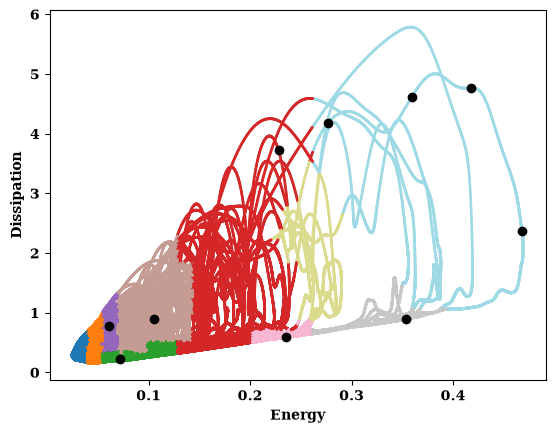

In [8]:
t=[sim_time[29714],sim_time[29831],sim_time[29911],sim_time[30013],sim_time[30030],sim_time[30038],sim_time[30049],sim_time[30062],sim_time[30112],sim_time[30155]]
figo, axo = plt.subplots()
axo.scatter(DE[:, 1], DE[:, 0], s=1, c=cluster_colors,zorder=1)
for i in t:
    axo.scatter(DE[i, 1], DE[i, 0],c="black",zorder=10)
#axo.set_title(f'MFE Sim, dt={dt}, N={N-istart}, Re={Re}')
axo.set_xlabel("Energy",)
axo.set_ylabel("Dissipation")

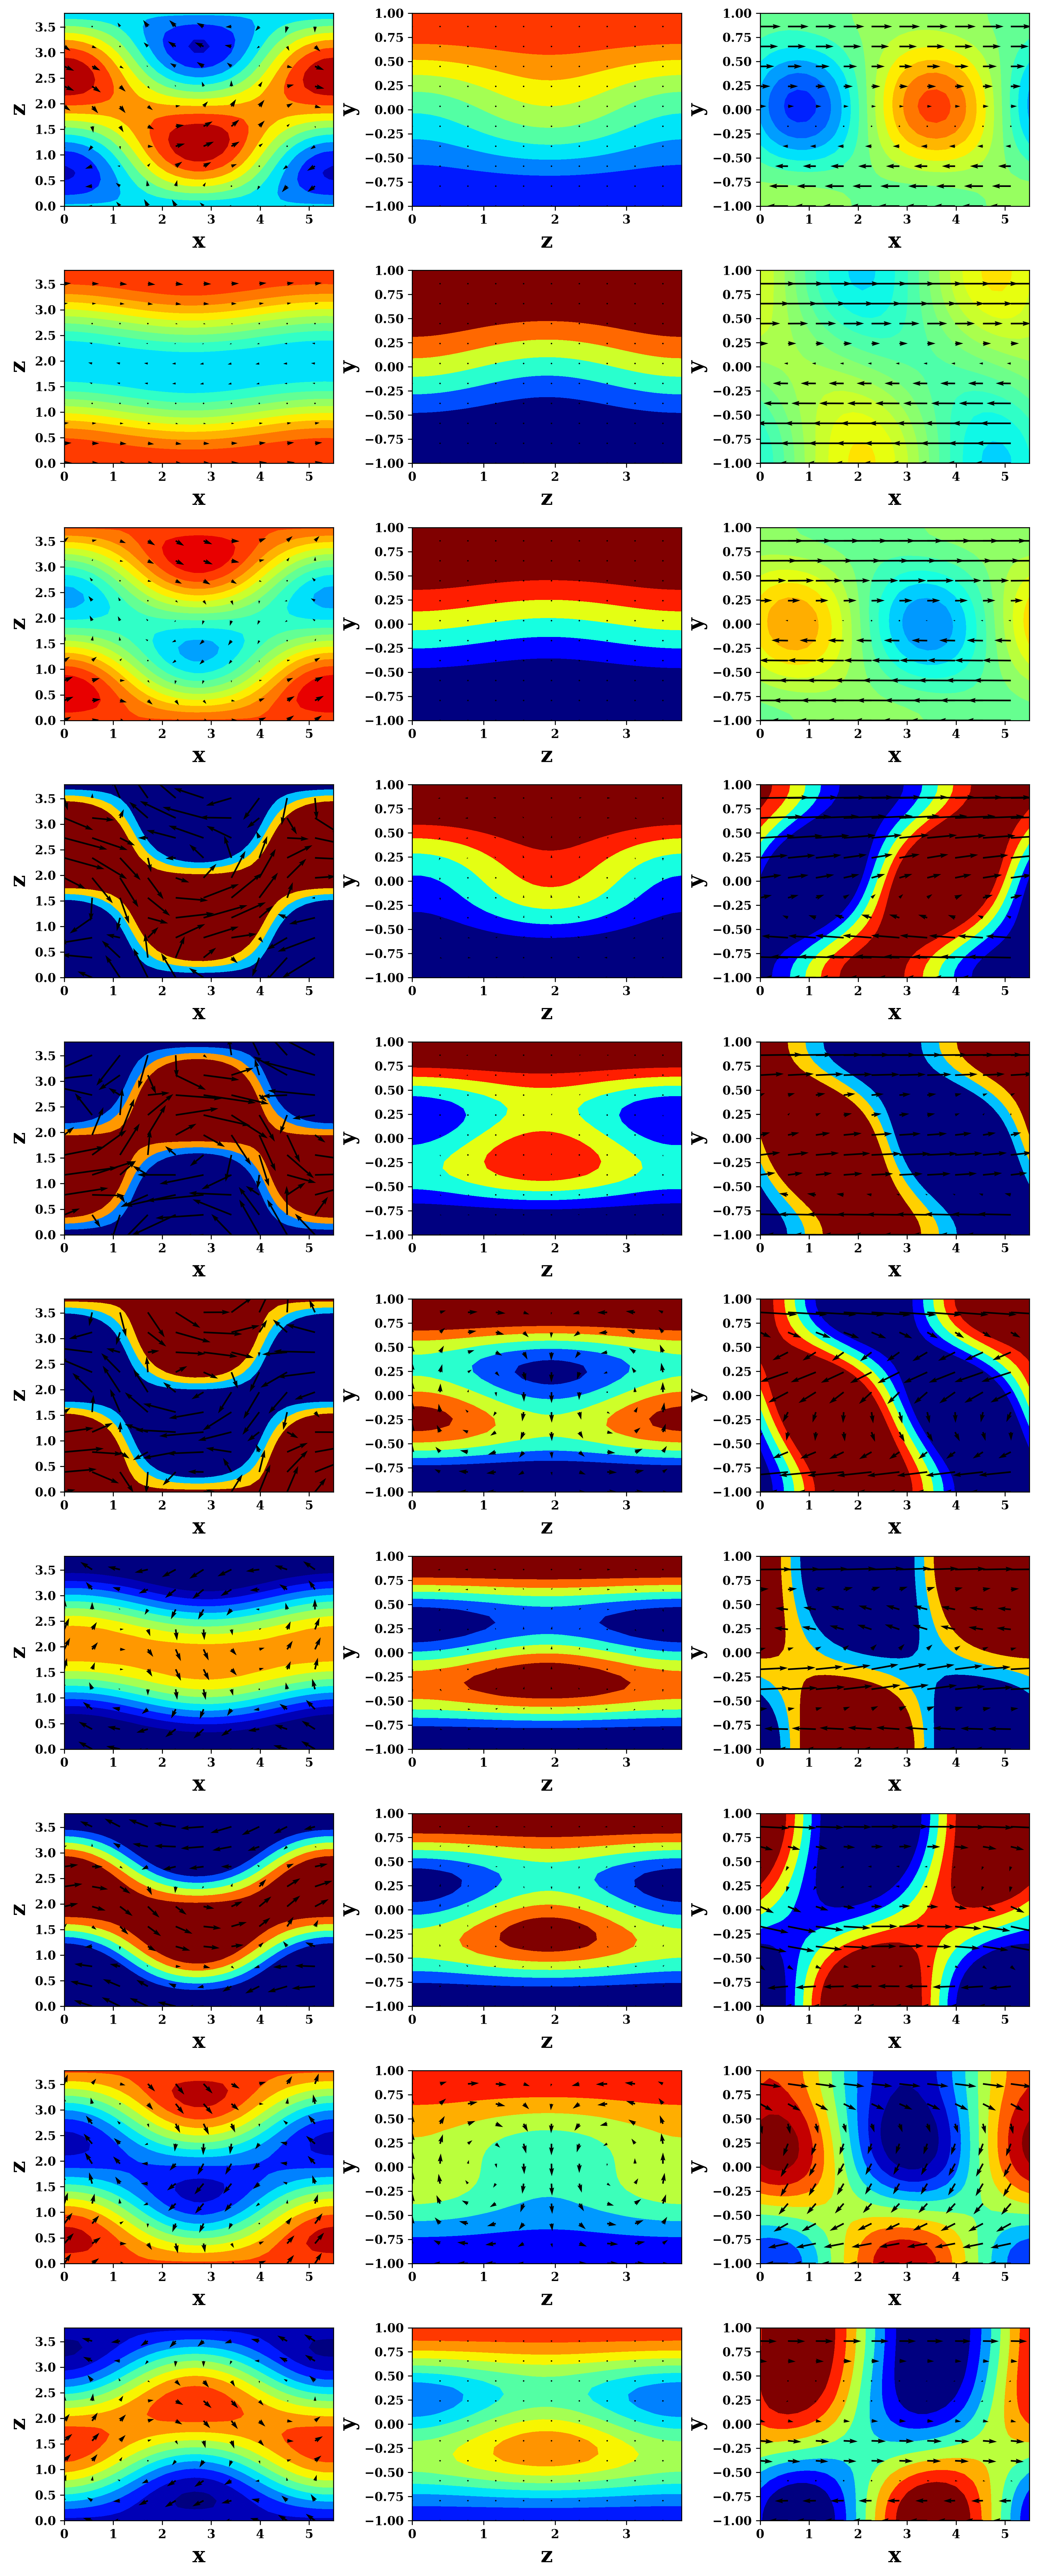

In [41]:
plt.close('all')
t=[sim_time[29714],sim_time[29831],sim_time[29911],sim_time[30013],sim_time[30030],sim_time[30038],sim_time[30049],sim_time[30062],sim_time[30112],sim_time[30155]]
fig, ax = plt.subplots(len(t),3,figsize=(12,3*len(t)),dpi=300)
k = discretize_size // 2
quiver_skip = 3
quiver_scale = 5
vmin_1, vmax_1  = -0.2, 0.2
norm_1      = colors.Normalize(vmin=vmin_1, vmax=vmax_1)
tick_values_1 = np.linspace(vmin_1, vmax_1, 5)
sm1         = ScalarMappable(norm=norm_1, cmap='jet')
vmin_2, vmax_2  = -0.5, 0.5
norm_2      = colors.Normalize(vmin=vmin_2, vmax=vmax_2)
tick_values_2 = np.linspace(vmin_2, vmax_2, 5)
sm2         = ScalarMappable(norm=norm_2, cmap='jet')
vmin_3, vmax_3  = -0.2, 0.2
norm_3      = colors.Normalize(vmin=vmin_3, vmax=vmax_3)
tick_values_3 = np.linspace(vmin_3, vmax_3, 5)
sm3         = ScalarMappable(norm=norm_3, cmap='jet')

for i,timer in enumerate(t):

    U_val=np.load(os.path.join(data_path,f"{timer}.npz"))
    U,V,W=U_val["U"],U_val["V"],U_val["W"]

    #fig.suptitle(f"Velocity Field at t={t*dt:.2f}", fontsize=16, fontweight='bold')
    # --------------------------------------------------
    # Plot Z-X-Plane
    # --------------------------------------------------

    X2D = X[:, k, :]
    Z2D = Z[:, k, :]

    U2D = U[:, k, :]
    V2D = V[:, k, :]
    W2D = W[:, k, :]

    # Colored contour
    cont = ax[i,0].contourf(
        X2D,
        Z2D,
        U2D,
        levels=10,
        cmap='jet',norm=norm_1
    )

    ax[i,0].quiver(
        X2D[::quiver_skip, ::quiver_skip],
        Z2D[::quiver_skip, ::quiver_skip],
        U2D[::quiver_skip, ::quiver_skip],
        W2D[::quiver_skip, ::quiver_skip],
        color='k',
        scale=quiver_scale
    )

    # Labels
    ax[i,0].set_xlabel('x', fontsize=18, fontweight='bold')
    ax[i,0].set_ylabel('z', fontsize=18, fontweight='bold')

    # Colorbar
    #cbar = plt.colorbar(sm1,ax=ax[0],ticks=tick_values_1)
    #cbar.ax.tick_params(labelsize=14)
    #ax[i,0].tick_params(labelsize=14)


    # --------------------------------------------------
    # Plot Z-Y-Plane
    # --------------------------------------------------

    Y2D = Y[k, :, :]
    Z2D = Z[k, :, :]

    U2D = U.mean(axis=0)
    V2D = V.mean(axis=0)
    W2D = W.mean(axis=0)

    # Colored contour
    cont = ax[i,1].contourf(
        Z2D,
        Y2D,
        U2D,
        cmap='jet',norm=norm_2
    )

    ax[i,1].quiver(
        
        Z2D[::quiver_skip, ::quiver_skip],
        Y2D[::quiver_skip, ::quiver_skip],
        W2D[::quiver_skip, ::quiver_skip],
        V2D[::quiver_skip, ::quiver_skip],
        color='k',
        scale=quiver_scale
    )

    # Labels
    ax[i,1].set_xlabel('z', fontsize=18, fontweight='bold')
    ax[i,1].set_ylabel('y', fontsize=18, fontweight='bold')

    # Colorbar
    #cbar = plt.colorbar(sm2,ax=ax[1],ticks=tick_values_2)
    #cbar.ax.tick_params(labelsize=14)
    #ax[1].tick_params(labelsize=14)

    # --------------------------------------------------
    # Plot Y-X-Plane
    # --------------------------------------------------

    Y2D = Y[:, :, k]
    X2D = X[:, :, k]

    V2D = V[:, :, k]
    U2D = U[:, :, k]
    W2D = W[:, :, k]


    # Colored contour
    cont = ax[i,2].contourf(
        X2D,
        Y2D,
        W2D,
        levels=10,
        cmap='jet',norm=norm_3
    )

    ax[i,2].quiver(
        
        X2D[::quiver_skip, ::quiver_skip],
        Y2D[::quiver_skip, ::quiver_skip],
        U2D[::quiver_skip, ::quiver_skip],
        V2D[::quiver_skip, ::quiver_skip],
        color='k',
        scale=quiver_scale
    )

    # Labels
    ax[i,2].set_xlabel('x', fontsize=18, fontweight='bold')
    ax[i,2].set_ylabel('y', fontsize=18, fontweight='bold')

    # Colorbar
    #cbar = plt.colorbar(sm3,ax=ax[2],ticks=tick_values_3)
    #cbar.ax.tick_params(labelsize=14)

    #ax[2].tick_params(labelsize=14)

plt.tight_layout()
plt.show()


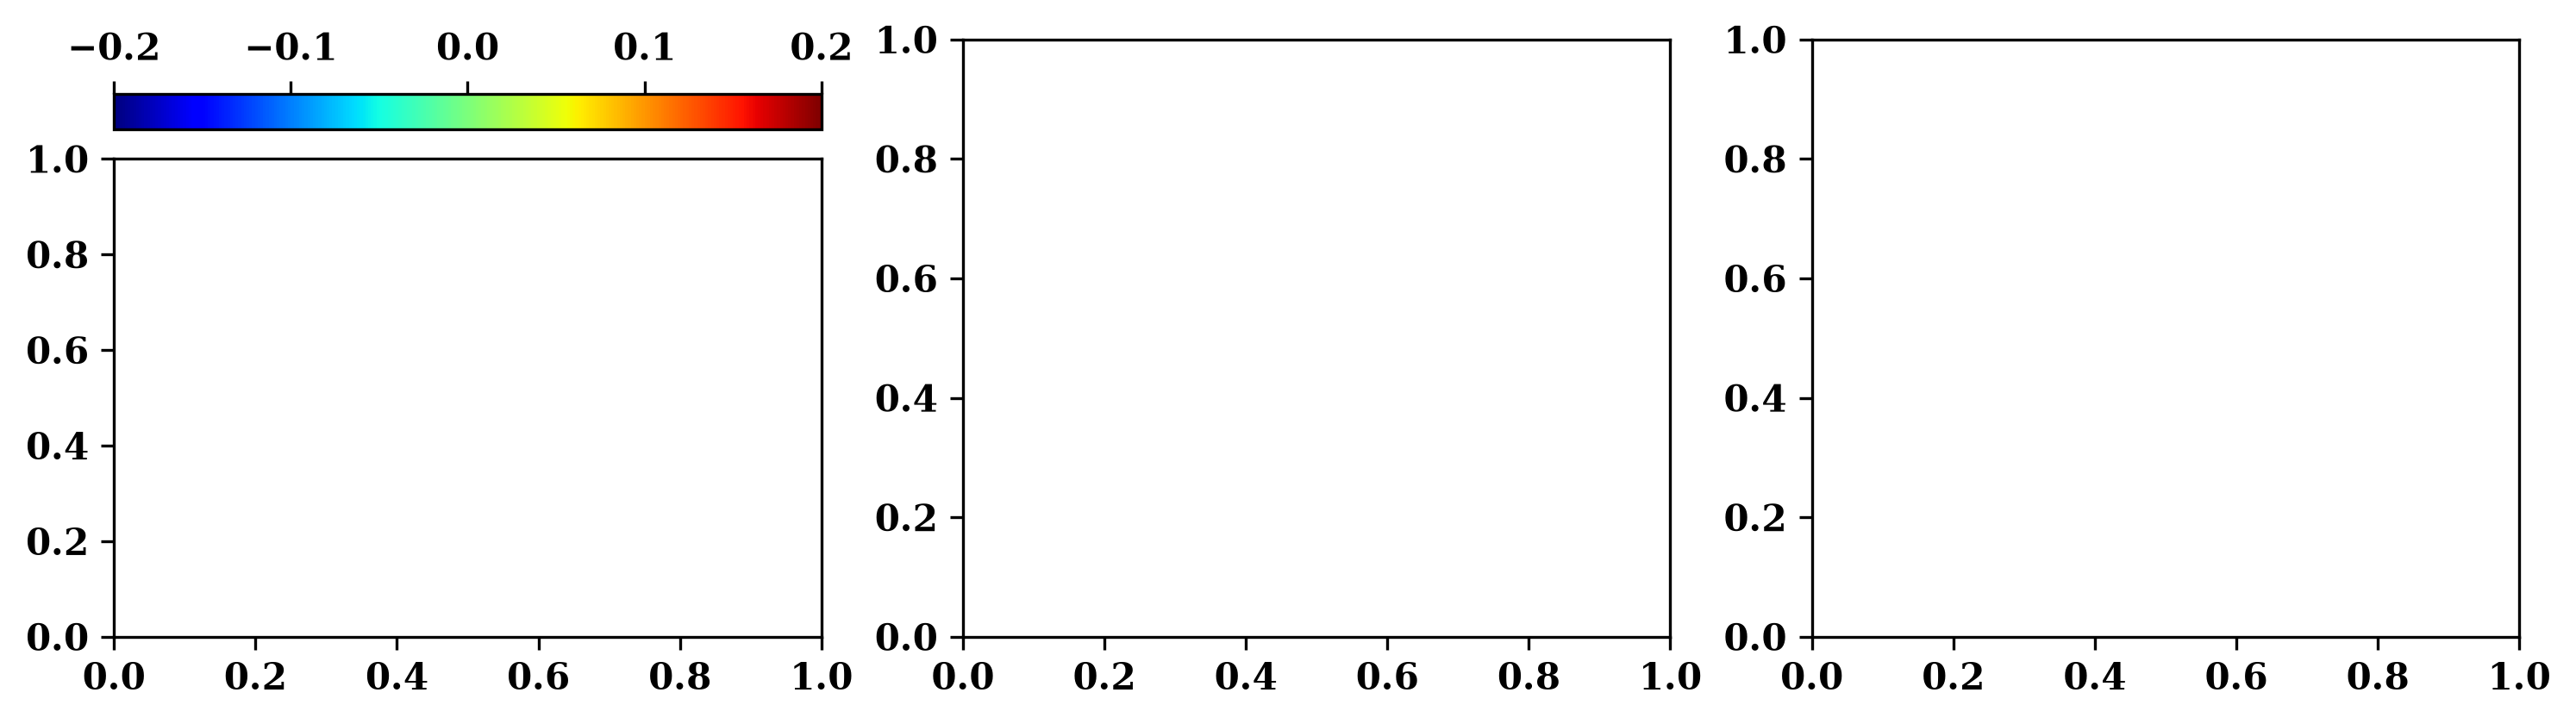

In [42]:
plt.close('all')
fig, ax = plt.subplots(1, 3, figsize=(12, 3), dpi=300)
k = discretize_size // 2
quiver_skip = 3
quiver_scale = 5
vmin_1, vmax_1  = -0.2, 0.2
norm_1      = colors.Normalize(vmin=vmin_1, vmax=vmax_1)
tick_values_1 = np.linspace(vmin_1, vmax_1, 5)
sm1         = ScalarMappable(norm=norm_1, cmap='jet')
vmin_2, vmax_2  = -0.5, 0.5
norm_2      = colors.Normalize(vmin=vmin_2, vmax=vmax_2)
tick_values_2 = np.linspace(vmin_2, vmax_2, 5)
sm2         = ScalarMappable(norm=norm_2, cmap='jet')
vmin_3, vmax_3  = -0.2, 0.2
norm_3      = colors.Normalize(vmin=vmin_3, vmax=vmax_3)
tick_values_3 = np.linspace(vmin_3, vmax_3, 5)
sm3         = ScalarMappable(norm=norm_3, cmap='jet')

cbar = plt.colorbar(sm1,ax=ax[0],ticks=tick_values_1,orientation='horizontal',location='top')


In [ ]:
#animate the Z-X plane funcanimation
plt.close('all')
fig, ax = plt.subplots(figsize=(10,4))

ax.tick_params(labelsize=14)
ax.set_xlabel('x', fontsize=18, fontweight='bold')
ax.set_ylabel('z', fontsize=18, fontweight='bold')

plt.tight_layout()

# ------------------------------------
# Load first frame
# ------------------------------------
with np.load(os.path.join(data_path, "0.npz")) as data:
    U = data["U"]
    V = data["V"]
    W = data["W"]

k = discretize_size // 2

X2D = X[:, k, :]
Z2D = Z[:, k, :]

U2D = U[:, k, :]
V2D = V[:, k, :]
W2D = W[:, k, :]

# ------------------------------------
# Colormap
# ------------------------------------
mesh = ax.contourf(
    X2D,
    Z2D,
    V2D,
    cmap="jet",
    levels=10
)

cbar = fig.colorbar(mesh, ax=ax)
cbar.ax.tick_params(labelsize=14)

# ------------------------------------
# Quiver
# ------------------------------------
skip = 3
scale = 3
quiv = ax.quiver(
    X2D[::skip, ::skip],
    Z2D[::skip, ::skip],
    U2D[::skip, ::skip],
    W2D[::skip, ::skip],
    color="k",
    scale=scale
)

# ------------------------------------
# Fixed axes
# ------------------------------------
ax.set_xlim(X2D.min(), X2D.max())
ax.set_ylim(Z2D.min(), Z2D.max())

# ------------------------------------
# Animation update
# ------------------------------------
def update(frame):

    with np.load(os.path.join(data_path, f"{frame}.npz")) as data:
        U = data["U"]
        V = data["V"]
        W = data["W"]

    U2D = U[:, k, :]
    V2D = V[:, k, :]
    W2D = W[:, k, :]

    # Update colormap
    mesh = ax.contourf(
    X2D,
    Z2D,
    V2D,
    cmap="jet",
    levels=10
    )

    # Update arrows
    quiv = ax.quiver(
        X2D[::skip, ::skip],
        Z2D[::skip, ::skip],
        U2D[::skip, ::skip],
        W2D[::skip, ::skip],
        color="k",
        scale=scale
    )
    ax.set_title(f"Time: {dt*frame}")
    return mesh, quiv

# ------------------------------------
# Animation
# ------------------------------------
animation = FuncAnimation(
    fig,
    update,
    frames=sim_time,
    interval=50,
    blit=False
)
writer = FFMpegWriter(fps=10)
animation.save("Videos/Z-X_Plane_test.mp4", writer=writer)

In [ ]:
#animate the Y-Z plane funcanimation

plt.close('all')
fig2, ax2 = plt.subplots(figsize=(10,4))

ax2.tick_params(labelsize=14)
ax2.set_xlabel('z', fontsize=18, fontweight='bold')
ax2.set_ylabel('y', fontsize=18, fontweight='bold')

plt.tight_layout()

# ------------------------------------
# Load first frame
# ------------------------------------
with np.load(os.path.join(data_path, "0.npz")) as data:
    U = data["U"]
    V = data["V"]
    W = data["W"]
U=U.mean(axis=0)
V=V.mean(axis=0)
W=W.mean(axis=0)
k = discretize_size // 2

Y2D = Y[k, :, :]
Z2D = Z[k, :, :]

U2D = U[ :, :]
V2D = V[ :, :]
W2D = W[ :, :]

# ------------------------------------
# Colormap
# ------------------------------------
mesh = ax2.contourf(
    Z2D,
    Y2D,
    U2D,
    cmap="jet",
    levels=10
)

cbar = fig2.colorbar(mesh, ax=ax)
cbar.ax2.tick_params(labelsize=14)

# ------------------------------------
# Quiver
# ------------------------------------
skip = 3
scale = 1
quiv = ax2.quiver(
    Z2D[::skip, ::skip],
    Y2D[::skip, ::skip],
    W2D[::skip, ::skip],
    V2D[::skip, ::skip],
    color="k",
    scale=scale
)

# ------------------------------------
# Fixed axes
# ------------------------------------
ax2.set_xlim(Z2D.min(), Z2D.max())
ax2.set_ylim(Y2D.min(), Y2D.max())

# ------------------------------------
# Animation update
# ------------------------------------
def update(frame):

    with np.load(os.path.join(data_path, f"{frame}.npz")) as data:
        U = data["U"].mean(axis=0)
        V = data["V"].mean(axis=0)
        W = data["W"].mean(axis=0)
    U2D = U
    V2D = V
    W2D = W

    # Update colormap
    mesh = ax2.contourf(
    Z2D,
    Y2D,
    U2D,
    cmap="jet",
    levels=10
    )

    # Update arrows
    quiv = ax2.quiver(
        Z2D[::skip, ::skip],
        Y2D[::skip, ::skip],
        W2D[::skip, ::skip],
        V2D[::skip, ::skip],
        color="k",
        scale=scale
    )
    
    ax2.set_title(f"Time: {dt*frame}")
    if frame*dt%1000==0: print(f"animated: {frame*dt}")
    return mesh, quiv

# ------------------------------------
# Animation
# ------------------------------------
animation = FuncAnimation(
    fig2,
    update,
    frames=sim_time,
    interval=50,
    blit=False
)
writer = FFMpegWriter(fps=10)
animation.save("Videos/Y-Z_Plane_test.mp4", writer=writer)

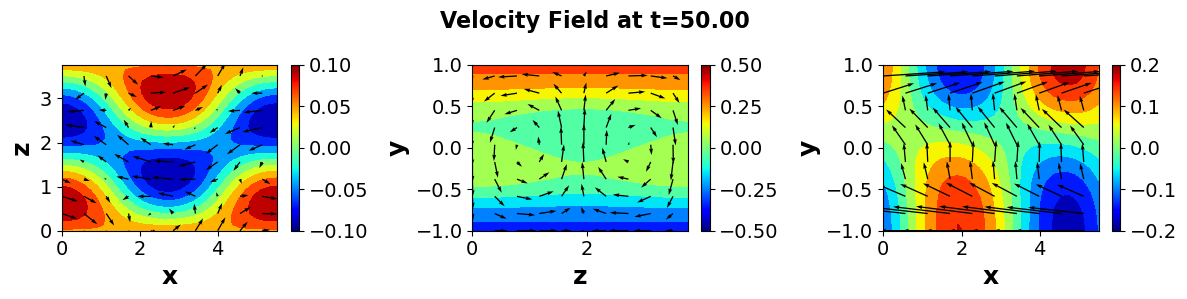

In [ ]:
t=1000
U_val=np.load(os.path.join(data_path,f"{t}.npz"))
U,V,W=U_val["U"],U_val["V"],U_val["W"]

k = discretize_size // 2
quiver_skip = 3
quiver_scale = 1
vmin_1, vmax_1  = -0.1, 0.1
norm_1      = colors.Normalize(vmin=vmin_1, vmax=vmax_1)
tick_values_1 = np.linspace(vmin_1, vmax_1, 5)
sm1         = ScalarMappable(norm=norm_1, cmap='jet')
vmin_2, vmax_2  = -0.5, 0.5
norm_2      = colors.Normalize(vmin=vmin_2, vmax=vmax_2)
tick_values_2 = np.linspace(vmin_2, vmax_2, 5)
sm2         = ScalarMappable(norm=norm_2, cmap='jet')
vmin_3, vmax_3  = -0.2, 0.2
norm_3      = colors.Normalize(vmin=vmin_3, vmax=vmax_3)
tick_values_3 = np.linspace(vmin_3, vmax_3, 5)
sm3         = ScalarMappable(norm=norm_3, cmap='jet')

plt.close('all')
fig, ax = plt.subplots(1,3,figsize=(12,3))
#fig.suptitle(f"Velocity Field at t={t*dt:.2f}", fontsize=16, fontweight='bold')
# --------------------------------------------------
# Plot Z-X-Plane
# --------------------------------------------------

X2D = X[:, k, :]
Z2D = Z[:, k, :]

U2D = U[:, k, :]
V2D = V[:, k, :]
W2D = W[:, k, :]

# Colored contour
cont = ax[0].contourf(
    X2D,
    Z2D,
    U2D,
    levels=10,
    cmap='jet'
)

ax[0].quiver(
    X2D[::quiver_skip, ::quiver_skip],
    Z2D[::quiver_skip, ::quiver_skip],
    U2D[::quiver_skip, ::quiver_skip],
    W2D[::quiver_skip, ::quiver_skip],
    color='k',
    scale=quiver_scale
)

# Labels
ax[0].set_xlabel('x', fontsize=18, fontweight='bold')
ax[0].set_ylabel('z', fontsize=18, fontweight='bold')

# Colorbar
cbar = plt.colorbar(sm1,ax=ax[0],ticks=tick_values_1)
cbar.ax.tick_params(labelsize=14)
ax[0].tick_params(labelsize=14)


# --------------------------------------------------
# Plot Z-Y-Plane
# --------------------------------------------------

Y2D = Y[k, :, :]
Z2D = Z[k, :, :]

U2D = U.mean(axis=0)
V2D = V.mean(axis=0)
W2D = W.mean(axis=0)

# Colored contour
cont = ax[1].contourf(
    Z2D,
    Y2D,
    U2D,
    cmap='jet',norm=norm_2
)

ax[1].quiver(
    
    Z2D[::quiver_skip, ::quiver_skip],
    Y2D[::quiver_skip, ::quiver_skip],
    W2D[::quiver_skip, ::quiver_skip],
    V2D[::quiver_skip, ::quiver_skip],
    color='k',
    scale=quiver_scale
)

# Labels
ax[1].set_xlabel('z', fontsize=18, fontweight='bold')
ax[1].set_ylabel('y', fontsize=18, fontweight='bold')

# Colorbar
cbar = plt.colorbar(sm2,ax=ax[1],ticks=tick_values_2)
cbar.ax.tick_params(labelsize=14)
ax[1].tick_params(labelsize=14)

# --------------------------------------------------
# Plot Y-X-Plane
# --------------------------------------------------

Y2D = Y[:, :, k]
X2D = X[:, :, k]

V2D = V[:, :, k]
U2D = U[:, :, k]
W2D = W[:, :, k]


# Colored contour
cont = ax[2].contourf(
    X2D,
    Y2D,
    W2D,
    levels=10,
    cmap='jet'
)

ax[2].quiver(
    
    X2D[::quiver_skip, ::quiver_skip],
    Y2D[::quiver_skip, ::quiver_skip],
    U2D[::quiver_skip, ::quiver_skip],
    V2D[::quiver_skip, ::quiver_skip],
    color='k',
    scale=quiver_scale
)

# Labels
ax[2].set_xlabel('x', fontsize=18, fontweight='bold')
ax[2].set_ylabel('y', fontsize=18, fontweight='bold')

# Colorbar
cbar = plt.colorbar(sm3,ax=ax[2],ticks=tick_values_3)
cbar.ax.tick_params(labelsize=14)

ax[2].tick_params(labelsize=14)

plt.tight_layout()
plt.show()


In [ ]:
##Print average cluster flow fields

cluster_stage=-1
num_clusters = max(A.CPT[cluster_stage])+1
cluster_points = {}
for i,cluster in enumerate(A.CPT[cluster_stage]):
    if cluster not in cluster_points:
        cluster_points[cluster] = []
    cluster_points[cluster].append(i)

###Plotting
k = discretize_size // 2
quiver_skip = 3
quiver_scale = 0.5
quiver_skip_X_Z = 3
quiver_scale_X_Z = 5
quiver_skip_Y_X = 3
quiver_scale_Y_X = 5
plt.close('all')

fig, ax = plt.subplots(num_clusters,3,figsize=(12,3*num_clusters))

vmin_1, vmax_1 = -0.2, 0.2
vmin_2, vmax_2 = -0.5, 0.5
vmin_3, vmax_3 = -0.2, 0.2

norm_1 = colors.Normalize(vmin_1, vmax_1)
norm_2 = colors.Normalize(vmin_2, vmax_2)
norm_3 = colors.Normalize(vmin_3, vmax_3)

tick_values_1 = np.linspace(vmin_1, vmax_1, num=5)
tick_values_2 = np.linspace(vmin_2, vmax_2, num=5)
tick_values_3 = np.linspace(vmin_3, vmax_3, num=5)
sm1 = ScalarMappable(norm=norm_1, cmap='jet')
sm2 = ScalarMappable(norm=norm_2, cmap='jet')
sm3 = ScalarMappable(norm=norm_3, cmap='jet')
for i,cluster in enumerate(cluster_points):
    ind=list(np.abs(sim_time[:, None]-cluster_points[cluster]).argmin(axis=0))
    sample_point=sim_time[ind]
    U_sum=0
    V_sum=0
    W_sum=0
    for point in sample_point:
        U_val=np.load(os.path.join(data_path,f"{point}.npz"))
        U,V,W=U_val["U"],U_val["V"],U_val["W"]
        U_sum=U_sum+U
        V_sum=V_sum+V
        W_sum=W_sum+W
    U_avg=U_sum/len(sample_point)
    V_avg=V_sum/len(sample_point)
    W_avg=W_sum/len(sample_point)
    
    # --------------------------------------------------
    # Plot Z-X-Plane
    # --------------------------------------------------

    X2DY = X[:, k, :]
    Z2DY = Z[:, k, :]
    U2DY = U_avg[:, k, :]
    V2DY = V_avg[:, k, :]
    W2DY = W_avg[:, k, :]

    # Colored contour
    cont0 = ax[i,0].contourf(
        X2DY,
        Z2DY,
        V2DY,
        levels=10,
        cmap='jet',
        #vmin=-0.2,
        #vmax=0.2,
        norm=norm_1
    )

    ax[i,0].quiver(
        X2DY[::quiver_skip_X_Z, ::quiver_skip_X_Z],
        Z2DY[::quiver_skip_X_Z, ::quiver_skip_X_Z],
        U2DY[::quiver_skip_X_Z, ::quiver_skip_X_Z],
        W2DY[::quiver_skip_X_Z, ::quiver_skip_X_Z],
        color='k',
        scale=quiver_scale_X_Z
    )

    # Labels
    ax[i,0].set_xlabel('x', fontsize=14, fontweight='bold')
    ax[i,0].set_ylabel(f'Cluster {i} \n z', fontsize=14, fontweight='bold')

    # --------------------------------------------------
    # Plot Z-Y-Plane
    # --------------------------------------------------

    Y2DX = Y[k, :, :]
    Z2DX = Z[k, :, :]

    U2DX = U_avg.mean(axis=0)
    V2DX = V_avg.mean(axis=0)
    W2DX = W_avg.mean(axis=0)

    # Colored contour
    cont1 = ax[i,1].contourf(
        Z2DX,
        Y2DX,
        U2DX,
        levels=10,
        cmap='jet',
        #vmin=-0.2,
        #vmax=0.2,
        norm=norm_2
    )

    ax[i,1].quiver(
        
        Z2DX[::quiver_skip, ::quiver_skip],
        Y2DX[::quiver_skip, ::quiver_skip],
        W2DX[::quiver_skip, ::quiver_skip],
        V2DX[::quiver_skip, ::quiver_skip],
        color='k',
        scale=quiver_scale
    )

    # Labels
    ax[i,1].set_xlabel('z', fontsize=14, fontweight='bold')
    ax[i,1].set_ylabel('y', fontsize=14, fontweight='bold')

    # Colorbar
    #cbar = plt.colorbar(cont,orientation='horizontal',location='top')
    #cbar.ax.tick_params(labelsize=14)

    #ax[i,1].tick_params(labelsize=14)

    # --------------------------------------------------
    # Plot Y-X-Plane
    # --------------------------------------------------

    Y2DZ = Y[:, :, k]
    X2DZ = X[:, :, k]

    V2DZ = V_avg[:, :, k]
    U2DZ = U_avg[:, :, k]
    W2DZ = W_avg[:, :, k]


    # Colored contour
    cont2 = ax[i,2].contourf(
        X2DZ,
        Y2DZ,
        W2DZ,
        levels=10,
        cmap='jet',
        #vmin=-0.2,
        #vmax=0.2,
        norm=norm_3
    )

    ax[i,2].quiver(
        
        X2DZ[::quiver_skip_Y_X, ::quiver_skip_Y_X],
        Y2DZ[::quiver_skip_Y_X, ::quiver_skip_Y_X],
        U2DZ[::quiver_skip_Y_X, ::quiver_skip_Y_X],
        V2DZ[::quiver_skip_Y_X, ::quiver_skip_Y_X],
        color='k',
        scale=quiver_scale_Y_X
    )

    # Labels
    ax[i,2].set_xlabel('x', fontsize=14, fontweight='bold')
    ax[i,2].set_ylabel('y', fontsize=14, fontweight='bold')

    # Colorbar
    #cbar = plt.colorbar(cont,orientation='horizontal',location='top')
    #cbar.ax.tick_params(labelsize=14)

    #ax[i,2].tick_params(labelsize=14)
fig.colorbar(sm1, ax=ax[0, 0], orientation='horizontal', location='top',ticks=tick_values_1)
fig.colorbar(sm2, ax=ax[0, 1], orientation='horizontal', location='top',ticks=tick_values_2)
fig.colorbar(sm3, ax=ax[0, 2], orientation='horizontal', location='top',ticks=tick_values_3)

plt.tight_layout()
plt.show()



In [ ]:
#plot random snapshots from clusters Y-Z plane
cluster_stage=-1
num_clusters = max(A.CPT[cluster_stage])+1
cluster_points = {}
for i,cluster in enumerate(A.CPT[cluster_stage]):
    if cluster not in cluster_points:
        cluster_points[cluster] = []
    cluster_points[cluster].append(i)

k = discretize_size // 2
quiver_skip = 3
quiver_scale = 1
plt.close('all')

fig, ax = plt.subplots(num_clusters//3,3,figsize=(16,3*(num_clusters//3)),dpi=300)

vmin_1, vmax_1 = -1, 1
norm_1 = colors.Normalize(vmin_1, vmax_1)
tick_values_1 = np.linspace(vmin_1, vmax_1, num=5)
sm1 = ScalarMappable(norm=norm_1, cmap='jet')

def sim_random_clusters(frame):   
    random_points=[]
    for i,cluster in enumerate(cluster_points):
        rand = random.randint(1, len(cluster_points[cluster]))
        random_points.append(cluster_points[cluster][rand-1])
    ind=list(np.abs(sim_time[:, None]-random_points).argmin(axis=0))
    random_points=sim_time[ind]

    ###Plotting


    for i, center_point in enumerate(random_points):
        U_val=np.load(os.path.join(data_path,f"{center_point}.npz"))
        U,V,W=U_val["U"],U_val["V"],U_val["W"]

        Y2DX = Y[k, :, :]
        Z2DX = Z[k, :, :]

        U2DX = U.mean(axis=0)
        V2DX = V.mean(axis=0)
        W2DX = W.mean(axis=0)

        # Colored contour
        cont1 = ax[i//3,i%3].contourf(
            Z2DX,
            Y2DX,
            U2DX,
            levels=10,
            cmap='jet',
            #vmin=-0.2,
            #vmax=0.2,
            norm=norm_1
        )

        ax[i//3,i%3].quiver(
            
            Z2DX[::quiver_skip, ::quiver_skip],
            Y2DX[::quiver_skip, ::quiver_skip],
            W2DX[::quiver_skip, ::quiver_skip],
            V2DX[::quiver_skip, ::quiver_skip],
            color='k',
            scale=quiver_scale
        )

        # Labels
        ax[i//3,i%3].set_xlabel(f' z', fontsize=14, fontweight='bold')
        ax[i//3,i%3].set_ylabel(f'Cluster {i} \n y', fontsize=14, fontweight='bold')
        # Colorbar
        #cbar = plt.colorbar(cont,orientation='horizontal',location='top')
        #cbar.ax.tick_params(labelsize=14)
        #ax[i,0].tick_params(labelsize=14)
        #cbar.set_ticks([-0.2, -0.1, 0, 0.1, 0.2])
    return fig, ax
#fig.colorbar(sm1, ax=ax[0, 0], orientation='horizontal', location='top',ticks=tick_values_1)

animation = FuncAnimation(
    fig,
    sim_random_clusters,
    frames=100,
    interval=50,
    blit=False
)
writer = FFMpegWriter(fps=4)
animation.save("Videos/Random_snapshots_from_cluster_animation_test.mp4", writer=writer)


In [ ]:
#plot random snapshots from clusters All planes
cluster_stage=-1
num_clusters = max(A.CPT[cluster_stage])+1
cluster_points = {}
for i,cluster in enumerate(A.CPT[cluster_stage]):
    if cluster not in cluster_points:
        cluster_points[cluster] = []
    cluster_points[cluster].append(i)

k = discretize_size // 2
quiver_skip = 3
quiver_scale = 3
plt.close('all')

fig, ax = plt.subplots(num_clusters,3,figsize=(12,3*num_clusters),dpi=300)

vmin_1, vmax_1 = -0.2, 0.2
vmin_2, vmax_2 = -0.5, 0.5
vmin_3, vmax_3 = -0.2, 0.2

norm_1 = colors.Normalize(vmin_1, vmax_1)
norm_2 = colors.Normalize(vmin_2, vmax_2)
norm_3 = colors.Normalize(vmin_3, vmax_3)

tick_values_1 = np.linspace(vmin_1, vmax_1, num=5)
tick_values_2 = np.linspace(vmin_2, vmax_2, num=5)
tick_values_3 = np.linspace(vmin_3, vmax_3, num=5)
sm1 = ScalarMappable(norm=norm_1, cmap='jet')
sm2 = ScalarMappable(norm=norm_2, cmap='jet')
sm3 = ScalarMappable(norm=norm_3, cmap='jet')
def sim_random_clusters(frame):   
    random_points=[]
    for i,cluster in enumerate(cluster_points):
        rand = random.randint(1, len(cluster_points[cluster]))
        random_points.append(cluster_points[cluster][rand-1])
    ind=list(np.abs(sim_time[:, None]-random_points).argmin(axis=0))
    random_points=sim_time[ind]

    ###Plotting


    for i, center_point in enumerate(random_points):
        U_val=np.load(os.path.join(data_path,f"{center_point}.npz"))
        U,V,W=U_val["U"],U_val["V"],U_val["W"]

        # --------------------------------------------------
        # Plot Z-X-Plane
        # --------------------------------------------------

        X2DY = X[:, k, :]
        Z2DY = Z[:, k, :]
        U2DY = U[:, k, :]
        V2DY = V[:, k, :]
        W2DY = W[:, k, :]

        # Colored contour
        cont0 = ax[i,0].contourf(
            X2DY,
            Z2DY,
            V2DY,
            levels=10,
            cmap='jet',
            #vmin=-0.2,
            #vmax=0.2,
            norm=norm_1
        )

        ax[i,0].quiver(
            X2DY[::quiver_skip, ::quiver_skip],
            Z2DY[::quiver_skip, ::quiver_skip],
            U2DY[::quiver_skip, ::quiver_skip],
            W2DY[::quiver_skip, ::quiver_skip],
            color='k',
            scale=quiver_scale
        )

        # Labels
        ax[i,0].set_xlabel('x', fontsize=14, fontweight='bold')
        ax[i,0].set_ylabel(f'Cluster {i} \n z', fontsize=14, fontweight='bold')

        # Colorbar
        #cbar = plt.colorbar(cont,orientation='horizontal',location='top')
        #cbar.ax.tick_params(labelsize=14)
        #ax[i,0].tick_params(labelsize=14)
        #cbar.set_ticks([-0.2, -0.1, 0, 0.1, 0.2])

        # --------------------------------------------------
        # Plot Z-Y-Plane
        # --------------------------------------------------

        Y2DX = Y[k, :, :]
        Z2DX = Z[k, :, :]

        U2DX = U[k, :, :]
        V2DX = V[k, :, :]
        W2DX = W[k, :, :]

        # Colored contour
        cont1 = ax[i,1].contourf(
            Z2DX,
            Y2DX,
            U2DX,
            levels=10,
            cmap='jet',
            #vmin=-0.2,
            #vmax=0.2,
            norm=norm_2
        )

        ax[i,1].quiver(
            
            Z2DX[::quiver_skip, ::quiver_skip],
            Y2DX[::quiver_skip, ::quiver_skip],
            W2DX[::quiver_skip, ::quiver_skip],
            V2DX[::quiver_skip, ::quiver_skip],
            color='k',
            scale=quiver_scale
        )

        # Labels
        ax[i,1].set_xlabel('z', fontsize=14, fontweight='bold')
        ax[i,1].set_ylabel('y', fontsize=14, fontweight='bold')

        # Colorbar
        #cbar = plt.colorbar(cont,orientation='horizontal',location='top')
        #cbar.ax.tick_params(labelsize=14)

        #ax[i,1].tick_params(labelsize=14)

        # --------------------------------------------------
        # Plot Y-X-Plane
        # --------------------------------------------------

        Y2DZ = Y[:, :, k]
        X2DZ = X[:, :, k]

        V2DZ = V[:, :, k]
        U2DZ = U[:, :, k]
        W2DZ = W[:, :, k]


        # Colored contour
        cont2 = ax[i,2].contourf(
            X2DZ,
            Y2DZ,
            W2DZ,
            levels=10,
            cmap='jet',
            #vmin=-0.2,
            #vmax=0.2,
            norm=norm_3
        )

        ax[i,2].quiver(
            
            X2DZ[::quiver_skip, ::quiver_skip],
            Y2DZ[::quiver_skip, ::quiver_skip],
            U2DZ[::quiver_skip, ::quiver_skip],
            V2DZ[::quiver_skip, ::quiver_skip],
            color='k',
            scale=quiver_scale
        )

        # Labels
        ax[i,2].set_xlabel('x', fontsize=14, fontweight='bold')
        ax[i,2].set_ylabel('y', fontsize=14, fontweight='bold')

        # Colorbar
        #cbar = plt.colorbar(cont,orientation='horizontal',location='top')
        #cbar.ax.tick_params(labelsize=14)

        #ax[i,2].tick_params(labelsize=14)


    return fig, ax
fig.colorbar(sm1, ax=ax[0, 0], orientation='horizontal', location='top',ticks=tick_values_1)
fig.colorbar(sm2, ax=ax[0, 1], orientation='horizontal', location='top',ticks=tick_values_2)
fig.colorbar(sm3, ax=ax[0, 2], orientation='horizontal', location='top',ticks=tick_values_3)
animation = FuncAnimation(
    fig,
    sim_random_clusters,
    frames=50,
    interval=50,
    blit=False
)
writer = FFMpegWriter(fps=3)
animation.save("Videos/Random_snapshots_from_cluster_animation_test_all_planes.mp4", writer=writer)


In [ ]:
#animate the Y-X plane funcanimation

with np.load(os.path.join(data_path, "0.npz")) as data:
    U = data["U"]
    V = data["V"]
    W = data["W"]

plt.close('all')
fig3, ax3 = plt.subplots(figsize=(10,4))

ax3.tick_params(labelsize=14)
ax3.set_xlabel('x', fontsize=18, fontweight='bold')
ax3.set_ylabel('y', fontsize=18, fontweight='bold')
plt.tight_layout()

k = discretize_size // 2

X2D = X[:, :, k]
Y2D = Y[:, :, k]

U2D = U[:, :, k]
V2D = V[:, :, k]
W2D = W[:, :, k]

# ------------------------------------
# Colormap
# ------------------------------------
mesh = ax3.contourf(
    X2D,
    Y2D,
    W2D,
    cmap="jet"
)

cbar = fig3.colorbar(mesh, ax=ax3)
cbar.ax3.tick_params(labelsize=14)

# ------------------------------------
# Quiver
# ------------------------------------
skip = 5
scale=5
quiv = ax3.quiver(
    X2D[::skip, ::skip],
    Y2D[::skip, ::skip],
    U2D[::skip, ::skip],
    V2D[::skip, ::skip],
    color="k",
    scale=scale
)

# ------------------------------------
# Fixed axes
# ------------------------------------
ax3.set_xlim(X2D.min(), X2D.max())
ax3.set_ylim(Y2D.min(), Y2D.max())

# ------------------------------------
# Animation update
# ------------------------------------
def update(frame):

    with np.load(os.path.join(data_path, f"{frame}.npz")) as data:
        U = data["U"]
        V = data["V"]
        W = data["W"]

    U2D = U[:, :, k]
    V2D = V[:, :, k]
    W2D = W[:, :, k]

    # Update colormap
    mesh = ax3.contourf(
    X2D,
    Y2D,
    W2D,
    cmap="jet"
    )

    # Update arrows
    quiv = ax3.quiver(
        X2D[::skip, ::skip],
        Y2D[::skip, ::skip],
        U2D[::skip, ::skip],
        V2D[::skip, ::skip],
        color="k",
        scale=scale
    )
    ax3.set_title(f"Time: {dt*frame}")
    return mesh, quiv

# ------------------------------------
# Animation
# ------------------------------------
animation = FuncAnimation(
    fig3,
    update,
    frames=sim_time,
    interval=50,
    blit=False
)
writer = FFMpegWriter(fps=10)
animation.save("Videos/Y-X_Plane_test.mp4", writer=writer)